(class2_exercise4)=
# Exercise 4. Using Text-Level Metrics
As we spoke about in the lecture, an alternative way to represent text for classification could be via metrics like [POS tag](23-parts-of-speech-analysis=) proportions, sentence length or *readability*. 

In [22]:
## CODE CHUNK REMOVED FOR USERS - HERE TO RELOAD DATA ##
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

## LOAD DATA ## 
# path of notebook
path = Path.cwd()

data_path = path.parents[1] / "resources" / "data" / "raid" / "train_none.csv"

raw_df = pd.read_csv(data_path)

## SUBSET DATA ##
df = raw_df[raw_df["model"].isin(["human", "cohere"])]

df["is_human"] = df["model"].apply(lambda x: 1 if x == "human" else 0)

## SPLIT DATA ##
train_df, val_df= train_test_split(
                                                    df,
                                                    test_size=0.20,
                                                    random_state=42,
                                                    stratify=df["is_human"]
                                                    )

/var/folders/gg/gk923hkx2w3bw72pk2shplydry9j0b/T/ipykernel_84715/1245980808.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["is_human"] = df["model"].apply(lambda x: 1 if x == "human" else 0)


In [23]:
# THIS CHUNK IS HIDDEN FROM USERS - FUNCTIONS TO FIT AND EVALUATE CLASSIFIER FROM LAST NOTEBOOK ##
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

def clf_fit(X_train, y_train, random_state=42):
    """
    Fit a classifier on X and Y

    Could for example be X_train = X_train_bow and y_train = train_df['is_human']
    """
    clf = LogisticRegression(
    random_state=random_state,
    solver="liblinear",   # better for small/medium sparse datasets
    max_iter=1000,        # allow more iterations
    C=1.0,                # adjust if needed (smaller values = stronger regularization)
    )

    clf.fit(X_train, y_train)

    return clf

def clf_evaluate(clf_fitted, X_val, y_val):
    """
    Evaluate fitted classifier, extracting y_pred from X_val, and creating a classification report
    """
    y_pred = clf_fitted.predict(X_val)

    report = classification_report(y_val, y_pred)

    return report, y_pred 

## 4.1 Installing TextDescriptives
For this, we'll install the TextDescriptives package. This was actually developed by former cogsci legends {cite:t}`hansen_textdescriptives_2023`!!

In [24]:
%pip install textdescriptives==2.8.4


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


We also need to install *spacy* again!

In [25]:
%pip install spacy==3.8.7
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 10.7 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 4.2 "Downsizing" our Dataset
We’ll use the `cohere` vs `human` subset again, but since `spaCy` can be slow with a dataset this size, we’ll shrink it! This makes it harder to compare with our previous approaches, but think of it as a proof-of-concept!

:::{admonition} How slow though? 
:class: gray, dropdown
On a `u1-standard-h-8` UCloud machine, it takes ~15 minutes. This is fine for a take-home exam ;), but maybe too long for class. You can always ask me for tips if you want to use this for an exam!
:::

A quick way to downsize would be grabbing the first 3200 `train` and 800 `val` rows (keeping the 4:1 ratio), but that could throw off class balance even further. Instead, we’ll use scikit-learn’s `resample`:

In [26]:
from sklearn.utils import resample

train_df_small = resample(train_df,
                    replace=False,    # sample without replacement
                    n_samples=3200,  
                    random_state=42,  
                    stratify=train_df["is_human"]  # keep the same ratio of classes as OG data
                    )

val_df_small = resample(val_df,
                    replace=False,    # sample without replacement
                    n_samples=800,  
                    random_state=42,  
                    stratify=val_df["is_human"]  # keep the same ratio of classes
                    )

> This function can also used to *actually* balance classes by "downsampling" the majority class. See {ref}`Exercise 5.1 <51-resampling-classes>`. 

## 4.3 Extract Metrics

Import `textdescriptives` and `spacy`:

In [27]:
import textdescriptives as td
import spacy

Load our model:

In [28]:
nlp = spacy.load("en_core_web_sm")

We then add "text_descriptives" to our nlp pipeline! Remember the components in {numref}`spacy-pipeline` with "ner" and "tagger" - this is the same idea!

In [29]:
nlp.add_pipe("textdescriptives/all")

Let's convert our texts to `docs` (note it is the smaller dfs!):

In [30]:
train_docs = nlp.pipe(train_df_small["generation"], batch_size=16, n_process=-1) # use -1 to use all available cores. this way, if you have a larger machine, it will actually be more efficient.
val_docs = nlp.pipe(val_df_small["generation"], batch_size=16, n_process=-1)

### Your turn: Find Metrics to Extract
:::{admonition} HANDS-ON
:class: red
You can extract metrics as such: 
```python
train_metrics_df = td.extract_df(
                                    train_docs, 
                                    include_text=True, 
                                    metrics=["..", ".."] # this is pseudocode - check task!
                                    )
```
The additional `metrics` is not defined correctly in the snippet above. This is because I want you to choose which kinds of metrics you want (can be passed as a list).

**YOUR TASK**

1. Check the [docs](https://hlasse.github.io/TextDescriptives/extractors.html#textdescriptives.extractors.extract_df) and decide on which kinds of metrics you want to extract!
2. Extract the metrics for both `train_df` and `val_df`
3. Print one of the `metrics_df` to see how it looks!
:::

Solution:

In [31]:
train_metrics = td.extract_df(
                                    train_docs, 
                                    include_text=True, 
                                    metrics=["readability", "descriptive_stats"] # you can add more metrics here if you want!
                                    )

val_metrics = td.extract_df(
                                    val_docs, 
                                    include_text=True, 
                                    metrics=["readability", "descriptive_stats"] # you can add more metrics here if you want!
)

# might give a coherence warning, but I'm not extracting coherence here, so we'll ignore it!

/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/textdescriptives/components/coherence.py:44: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Span.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  similarities.append(sent.similarity(sents[i + order]))
/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/textdescriptives/components/coherence.py:44: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Span.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgemen

You should have something like this (with your chosen metrics):

In [32]:
print(train_metrics.columns.tolist())

['text', 'flesch_reading_ease', 'flesch_kincaid_grade', 'smog', 'gunning_fog', 'automated_readability_index', 'coleman_liau_index', 'lix', 'rix', 'token_length_mean', 'token_length_median', 'token_length_std', 'sentence_length_mean', 'sentence_length_median', 'sentence_length_std', 'syllables_per_token_mean', 'syllables_per_token_median', 'syllables_per_token_std', 'n_tokens', 'n_unique_tokens', 'proportion_unique_tokens', 'n_characters', 'n_sentences']


:::{admonition} Is it too slow? Activate TV-kitchen!
:class: tip, dropdown
While a subset should take ~2 minutes, sometimes it seems to be a little slower (annoying!!). For class, you can cheat and use my pre-extracted metrics:
```python
metrics_path = path.parents[1] / "resources" / "data" / "raid" / "metrics"

train_metrics = pd.read_csv(metrics_path / "train_metrics.csv")
val_metrics = pd.read_csv(metrics_path / "val_metrics.csv")
```
::::

## 4.4 Pre-Processing
### Combine Train and Val
Let's start by renaming the `text` column from our `metrics` dfs:

In [33]:
train_metrics = train_metrics.rename(columns={"text": "generation"})
val_metrics = val_metrics.rename(columns={"text": "generation"})

Let's use the `pd.merge` to combine the two dataframes on their shared column:

In [34]:
train_df_complete = pd.merge(train_df, train_metrics.drop_duplicates(), on="generation") # for some reason, there were duplicate rows in metrics_df, so I dropped them first
val_df_complete = pd.merge(val_df, val_metrics.drop_duplicates(), on="generation")

Check they are same length:

In [35]:
print(len(train_df_complete), len(val_df_complete))
print(len(train_df), len(val_df))

3227 801
32090 8023


### Check for NA's
Our logistic regression doesn't do well with NA's in our features, and we have a few of them in our feature `smog` from `textdescriptives`:

In [36]:
# print where NAN
print(train_df_complete.isna().sum())

id                                0
adv_source_id                     0
source_id                         0
model                             0
decoding                       1082
repetition_penalty             1082
attack                            0
domain                            0
title                             0
prompt                         1082
generation                        0
is_human                          0
flesch_reading_ease               0
flesch_kincaid_grade              0
smog                             48
gunning_fog                       0
automated_readability_index       0
coleman_liau_index                0
lix                               0
rix                               0
token_length_mean                 0
token_length_median               0
token_length_std                  0
sentence_length_mean              0
sentence_length_median            0
sentence_length_std               0
syllables_per_token_mean          0
syllables_per_token_median  

Curious why `smog` turns up with NA values ... maybe due to the way it is computed? (feel free to investigate by reading the [docs](https://hlasse.github.io/TextDescriptives/)!). 

We could choose to remove all rows with `smog`, but we could also just avoid training on the metric, and focus on other metrics in our classification! This way we'll avoid deleting data.

:::{admonition} What if I want to drop NA's for my chosen features?
:class: tip, dropdown
You can use the method `.dropna()` on your df: 

```python
train_df_filtered= train_df_small.dropna(
    subset=["smog"] # only drop rows where these cols are NA
)
```
If you don't specify `subset`, `.dropna()` will remove *any* row with an NA. Here, that would delete all rows where `prompt` is NA, which is the entire human class. Definitely not what we want!
:::

## 4.5 Classify Metrics
You should now have a dataframes containing metrics for both `train` and `val` that are also filtered! We'll select the metrics:

In [37]:
metrics_to_use = ["flesch_reading_ease", "sentence_length_median", "n_unique_tokens", "n_tokens", "automated_readability_index"] # you can change these to whatever you want!

# define X, y for train 
X_train = train_df_complete[metrics_to_use]
y_train = train_df_complete["is_human"]

# define x for val (we are not filtering val, just using all of it)
X_val = val_df_complete[metrics_to_use]
y_val = val_df_complete["is_human"]

### Your Turn: Use Your Pipeline Functions !

:::{admonition} HANDS-ON
:class: red
Now you'll reap the benefits of having defined functions in {ref}`Exercise 3 <class2-ex-pipeline>`
- Select the metrics you are interested in classifying and create `X_train` and `X_val` 
    - Check for NA's. Removed if needed (or avoid training on those metrics)
- Use the functions from your pipeline that are relevant to fit and evaluate a classifier on your new *metric* features! 
- Compare the results to BOW/TF-IDF. Are they worse? Or better?
- Try to play with a few different metric combinations (does it help that there are more?)
:::

#### Solution:
My solution, you might have another!

In [38]:
# I'm using the function I defined in the last exercise
clf = clf_fit(X_train, y_train)
report, y_pred = clf_evaluate(clf, X_val, y_val)
print(report)

# It seems much worse than our BOW/TF-IDF approaches .. 
# I can confirm that the image is the same even with the full dataset ;)

              precision    recall  f1-score   support

           0       0.69      0.93      0.80       533
           1       0.58      0.18      0.28       268

    accuracy                           0.68       801
   macro avg       0.64      0.56      0.54       801
weighted avg       0.66      0.68      0.62       801



:::{warning} 
We might have benefitted from normalizing our features (ensuring they are on the same scale) before fitting the logistic regression (see [Malato, 2022](https://www.yourdatateacher.com/2022/06/13/which-models-require-normalized-data/)). We will ignore this for simplicity :).
:::

(46-shap-values)=
## 4.6 Explainable ML with SHAP values (Quickguide)
Despite how the results may or may not have turned out, it might be fun to try to look into *what* kind of features were important for our classification. We can do this by extracting SHAP values.

> Note: This only works properly if you choose metrics that don't heavily correlate. If they do so, it will be make our interpretation unstable. Perhaps choosing "n_tokens" and "n_sentences" is too risky.

Let's start by installing and importing `shap` (and `matplotlib` for plotting)

In [39]:
%pip install shap matplotlib
import shap


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Run SHAP

In [40]:
# intialize and explainer
explainer = shap.Explainer(clf.predict_proba, X_train, seed=42)

# extract vals
shap_values = explainer(X_val) # see https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/migrating-to-new-api.html

Let's print its shape! It contains the length of val data, our five features, and 2 classes:

In [41]:
print(shap_values.shape)

(801, 5, 2)


### Plot SHAP

Let's plot explanations with respect to class 1 by selecting the index `1` on the last dimension (of our shape `(n_samples, n_features, n_classes)`). You can also plot explanations for class 0, but it is just a flipped image of this. Note x-axis is on log-odds!

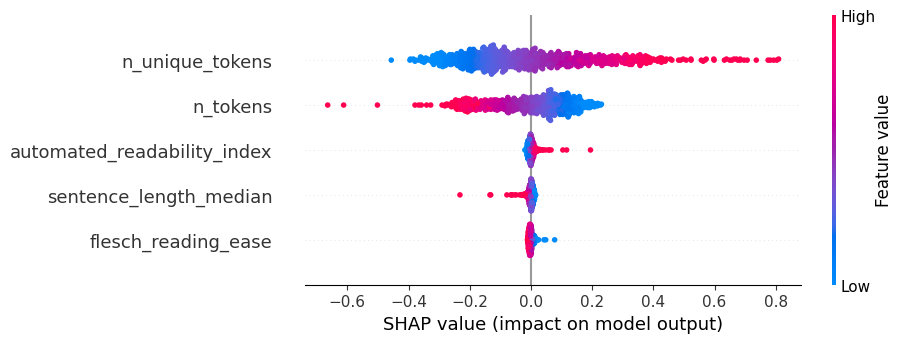

In [42]:
shap.plots.beeswarm(shap_values[:,:,1])

:::{admonition} HANDS-ON
:class: red
Whaaaaat is happening on this plot? See if you can find out how this should be interpreted!
- Try to skim through Aidan Cooper's [blog post](https://www.aidancooper.co.uk/a-non-technical-guide-to-interpreting-shap-analyses/). If that doesn't help, look at the SHAP library [docs](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html). Finally, there is also this [blogpost](https://towardsdatascience.com/explain-machine-learning-models-using-shap-library-e05a1583c34f/) from **TowardsDataScience**.

As a final task, try to run this SHAP workflow on your own chosen metrics!
:::

#### Solution: An Annotated SHAP plot
Below I've provided a quick annotation on how I interpret the beeswarm plot of shap values for class 1: 
:::{admonition} Annotation
:class: tip, dropdown
```{figure} ../figures/class2/shap-annotation.jpg
---
name: shap-annotation
---
```
Be aware that SHAP is just a decomposition of model predictions, trying to explain why the model outputs its predictions. Especially, when we deal with a questionable accuracy, it is not as if we can draw much insight into the features that correlate with AI-written vs. human text.
::::

:::{warning} 
Like everything else, SHAP values can also be unreliable. Read more about their [limitations](https://christophm.github.io/interpretable-ml-book/shap.html#limitations). 
- See also "[Be careful when interpreting predictive models in search of causal insights](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/Be%20careful%20when%20interpreting%20predictive%20models%20in%20search%20of%20causal%20insights.html)"

We can also go simple here and extract [feature importances](https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-in-logistic-regression-models/) from our logistic regression. What I like about SHAP values is their extra insights + ability to generalise across ML algs.
:::